In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

# Types of Time Series Data 
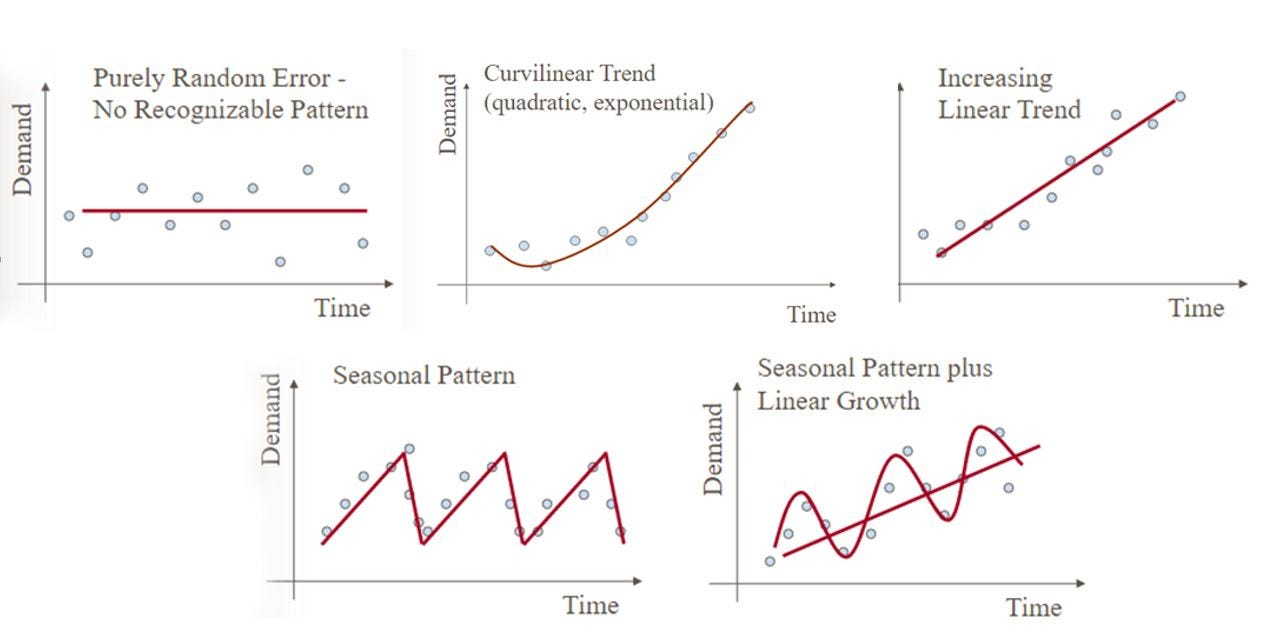

In [2]:
df = pd.read_csv('hourly-energy-consumption/PJME_hourly.csv')
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df = df.sort_index()

In [3]:
df.index.is_monotonic_increasing

True

In [4]:
df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


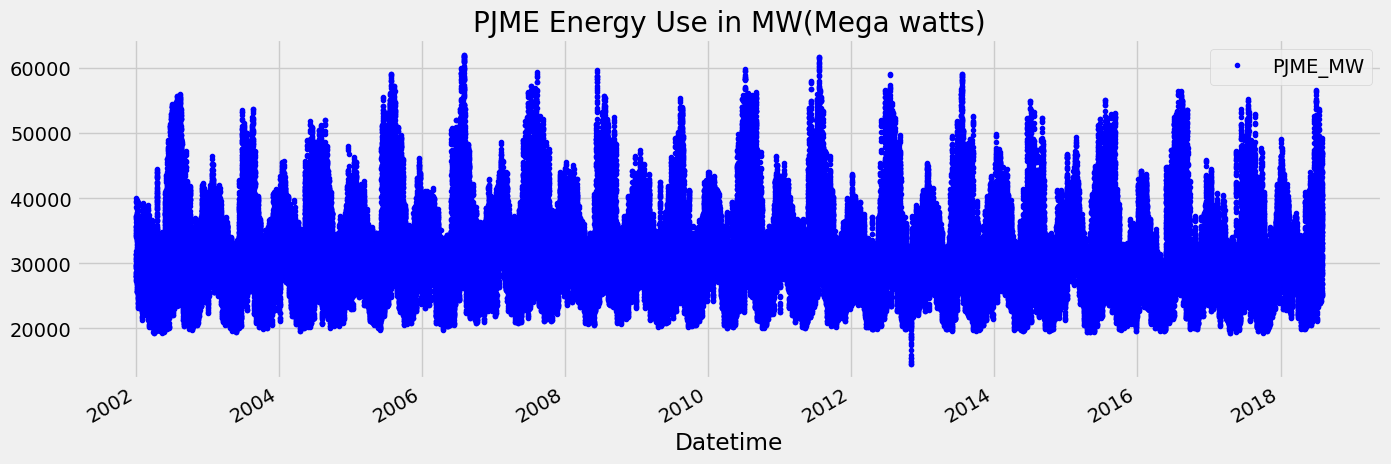

In [5]:
df.plot(style='.', figsize=(15,5), color='blue' , title='PJME Energy Use in MW(Mega watts)')
plt.show()

In [6]:
 pd.to_datetime(df.index)

DatetimeIndex(['2002-01-01 01:00:00', '2002-01-01 02:00:00',
               '2002-01-01 03:00:00', '2002-01-01 04:00:00',
               '2002-01-01 05:00:00', '2002-01-01 06:00:00',
               '2002-01-01 07:00:00', '2002-01-01 08:00:00',
               '2002-01-01 09:00:00', '2002-01-01 10:00:00',
               ...
               '2018-08-02 15:00:00', '2018-08-02 16:00:00',
               '2018-08-02 17:00:00', '2018-08-02 18:00:00',
               '2018-08-02 19:00:00', '2018-08-02 20:00:00',
               '2018-08-02 21:00:00', '2018-08-02 22:00:00',
               '2018-08-02 23:00:00', '2018-08-03 00:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=145366, freq=None)

# Train / Test Split 

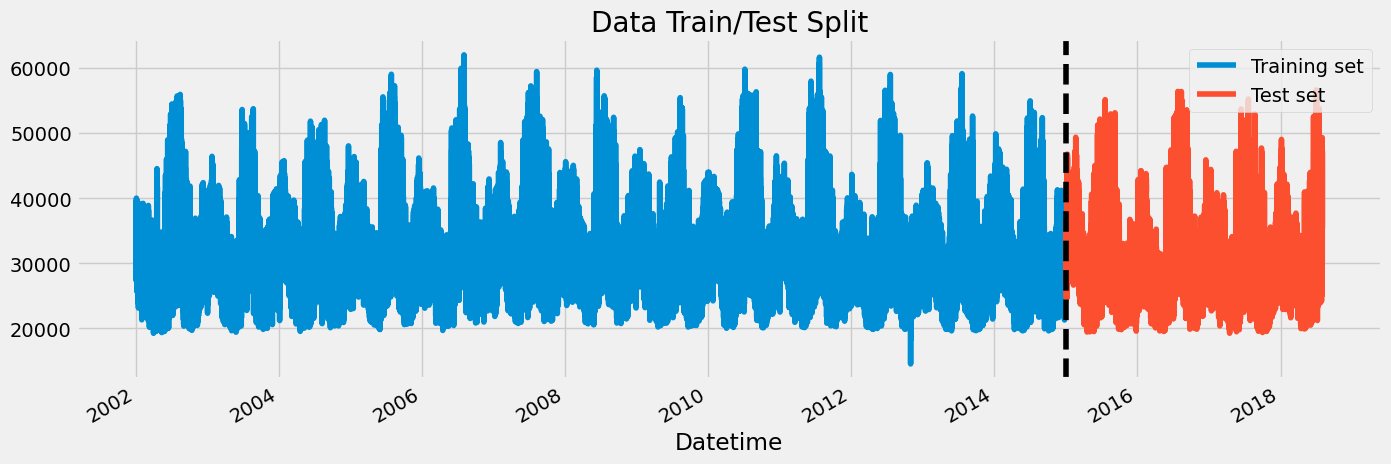

In [7]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

fig, ax=plt.subplots(figsize= (15,5))
train.plot(ax=ax, label='Training set', title='Data Train/Test Split')
test.plot(ax=ax, label='test set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training set', 'Test set'])
plt.show()

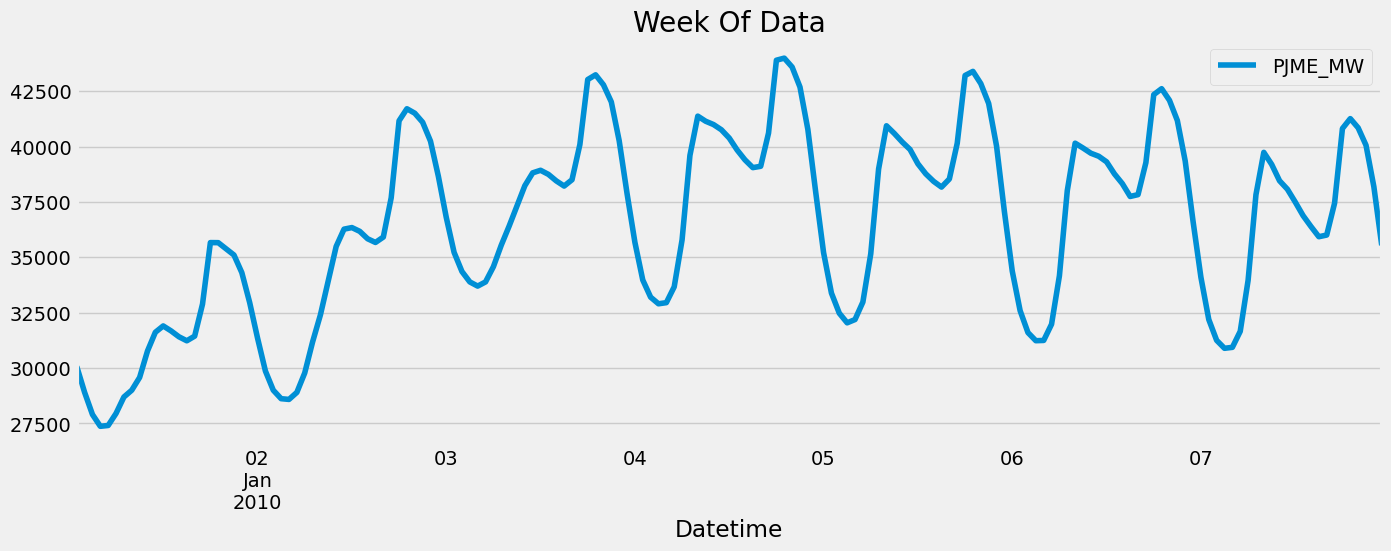

In [8]:
df.loc[(df.index > '01-01-2010') & ( df.index < '01-08-2010')].plot(figsize=(15,5), title='Week Of Data')
plt.show()

# Featuer Creation 

In [12]:
def create_feature(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.day_of_week
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    return df

df = create_feature(df)    

# Visualize our Feature / Target Relationship

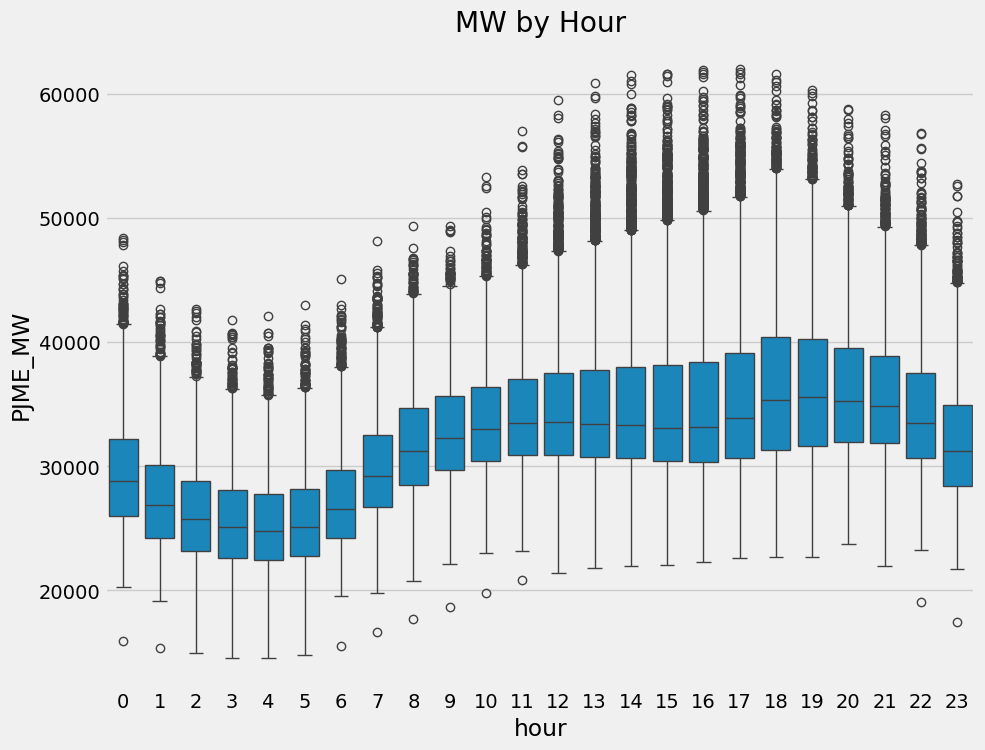

In [10]:
df['hour'] = df.index.hour

fig, ax = plt.subplots(figsize=(10,8))

sns.boxplot(data=df, x='hour', y='PJME_MW')

ax.set_title('MW by Hour')

plt.show()

C:\Users\vaiks\AppData\Local\Temp\ipykernel_22808\3723841773.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='PJME_MW', palette='Greens')


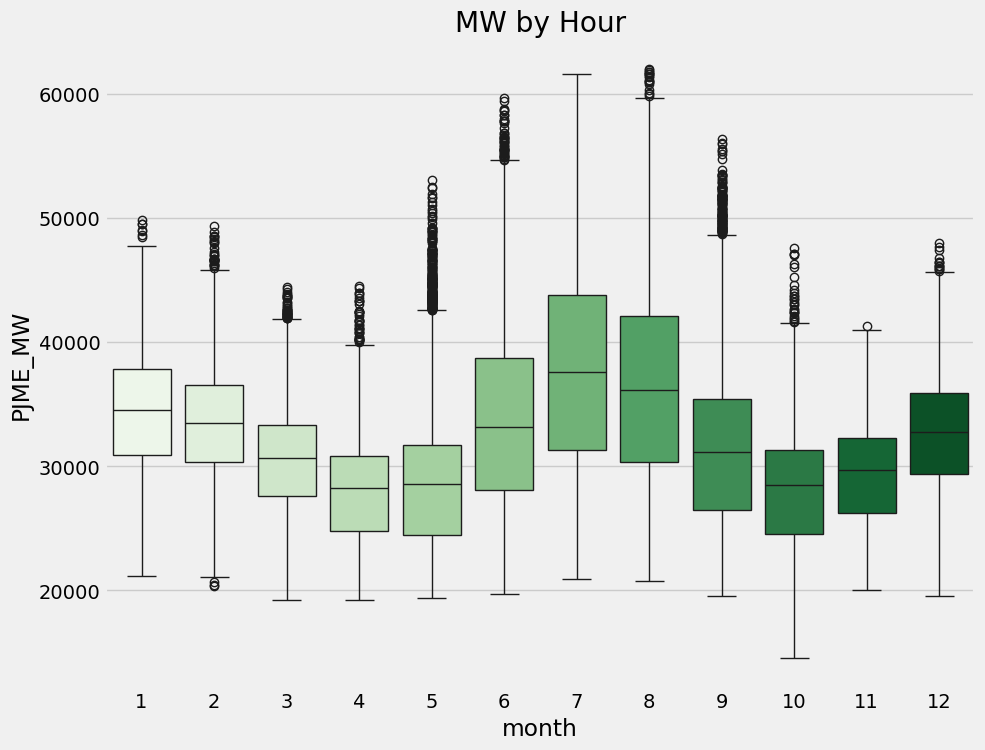

In [11]:
df['hour'] = df.index.hour

fig, ax = plt.subplots(figsize=(10,8))

sns.boxplot(data=df, x='month', y='PJME_MW', palette='Greens')

ax.set_title('MW by Hour')

plt.show()

# CReate Our Model 

In [14]:
df.columns

Index(['PJME_MW', 'hour', 'dayofweek', 'quarter', 'month', 'year',
       'dayofyear'],
      dtype='object')

In [15]:
train = create_feature(train)
test = create_feature(test)

Features= [ 'hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear']
Target = 'PJME_MW' 

In [18]:
X_train = train[Features]
y_train = train[Target]

X_test = test[Features]
y_test = test[Target]

In [21]:
reg = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50, learning_rate=0.001)
reg.fit(X_train, y_train, 
       eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100
       )

[0]	validation_0-rmse:6447.78573	validation_1-rmse:6517.54145
[100]	validation_0-rmse:6026.49339	validation_1-rmse:6131.08053
[200]	validation_0-rmse:5654.75124	validation_1-rmse:5796.65490
[300]	validation_0-rmse:5326.88030	validation_1-rmse:5505.59274
[400]	validation_0-rmse:5039.56899	validation_1-rmse:5253.21086
[500]	validation_0-rmse:4788.58887	validation_1-rmse:5034.74880
[600]	validation_0-rmse:4565.97498	validation_1-rmse:4847.76655
[700]	validation_0-rmse:4372.19812	validation_1-rmse:4687.11295
[800]	validation_0-rmse:4202.53312	validation_1-rmse:4547.57144
[900]	validation_0-rmse:4055.65261	validation_1-rmse:4427.00726
[999]	validation_0-rmse:3929.32983	validation_1-rmse:4325.35302


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


# Feature Importance

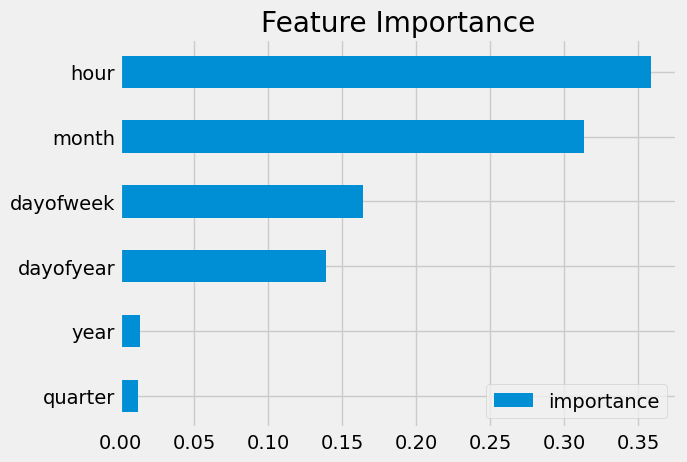

In [24]:
fi = pd.DataFrame(data= reg.feature_importances_, index= reg.feature_names_in_, columns=['importance'])

fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

# Forcast On Test

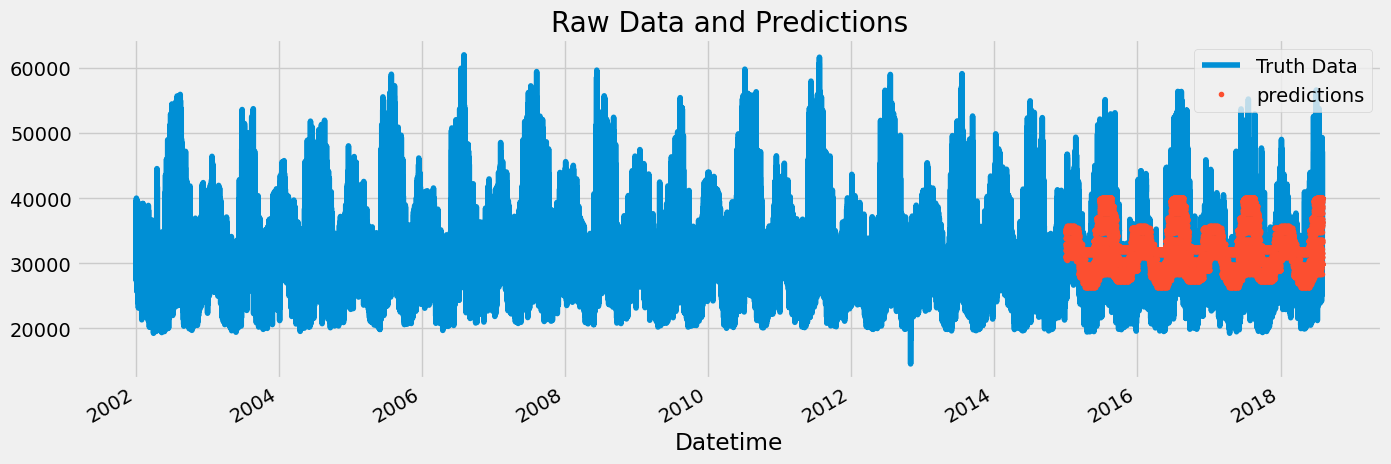

In [33]:
test['prediction'] = reg.predict(X_test)
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)

ax = df[['PJME_MW']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'predictions'])
ax.set_title('Raw Data and Predictions')
plt.show()

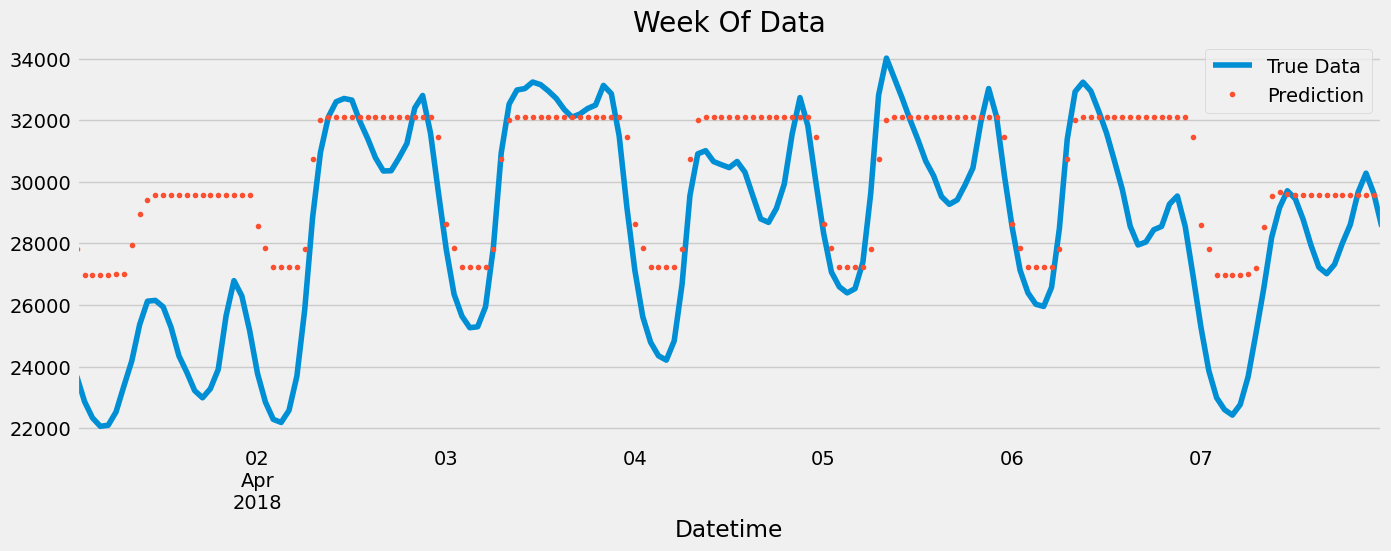

In [37]:
df.loc[(df.index > '2018-04-01') & (df.index < '2018-04-08')]['PJME_MW'] \
    .plot(figsize=(15,5), title='Week Of Data')

df.loc[(df.index > '2018-04-01') & (df.index < '2018-04-08')]['prediction'] \
    .plot(style='.')

plt.legend(['True Data','Prediction'])
plt.show()

In [40]:
score = np.sqrt(mean_squared_error(test['PJME_MW'], test['prediction']))
print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 4325.35


# Calcualte The Error
* Look at worst and best predicated days 

In [42]:
test['error'] = np.abs(test[Target] - test['prediction'])

In [44]:
test['date'] = test.index.date

In [47]:
test.groupby('date')['error'].mean().sort_values(ascending=False).head(10)

date
2016-08-13    12092.418620
2016-08-14    11407.225098
2018-01-06    11024.924316
2015-02-20    10791.006348
2016-09-09    10337.963704
2015-02-16    10183.015137
2016-09-10    10045.417725
2018-01-05     9977.450684
2018-01-07     9726.312012
2016-08-12     9678.751790
Name: error, dtype: float64

# IMPROVEMENTS I CAN MAKE IN FUTURE
* More robust cross Validation
* add more features( weather forecast, holidays)